# TaaSim — Trajectory Preprocessing & Map-Matching Pipeline
**Notebook 03 — Porto GPS patterns -> Casablanca road-snapped trajectories (H3 edition)**

### Pipeline overview
```
Porto POLYLINE
  1. Parse & validate (speed filter, dedup)
  2. Load real Casablanca polygon (OSMnx geocode)
  3. Build H3 hexagonal grid clipped to polygon
  4. Compute spatial weights (density + coast proximity)
  5. Adapt Porto trajectories -> Casablanca (preserve length + temporal patterns)
  6. Snap adapted points to road network (OSMnx + NetworkX)
  7. Assign zone_id (zone_mapping.csv) + H3 index
  8. Aggregate: trip density, flow, hotspots per H3 cell
  9. Visualise: polygon + H3 grid + trajectories + heatmap
```

| Constraint | Solution |
|------------|----------|
| No rectangular bounding boxes | OSMnx geocoded polygon |
| Spatial filtering | Point-in-polygon (Shapely) |
| Zone system | zone_mapping.csv centroids aligned to H3 |
| Resolution tuning | `H3_RESOLUTION` constant |
| Weight calibration | `calibrate_weights()` from data |


## 1  Install dependencies

In [47]:
import subprocess, sys

LIBS = [
    'osmnx==1.9.4',
    'h3==4.1.0',
    'geopandas',
    'shapely',
    'folium',
    'networkx',
    'scipy',
    'matplotlib',
]

for lib in LIBS:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'],
                          stderr=subprocess.DEVNULL)
print('All dependencies ready.')


All dependencies ready.


## 2  Imports

In [49]:
import ast
import json
import logging
import math
import time
import warnings
from collections import defaultdict
from pathlib import Path

import folium
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from folium.plugins import HeatMap
from shapely.geometry import Point, Polygon, MultiPolygon

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s  %(message)s')
logger = logging.getLogger('taasim.trajectory')

print(f'osmnx   {ox.__version__}')
print(f'h3      {h3.__version__}')
print(f'gpd     {gpd.__version__}')


osmnx   1.9.4
h3      4.1.0
gpd     0.14.4


## 3  Configuration — all tuneable parameters in one place

In [51]:
# H3 resolution: 5=~252km2, 6=~36km2, 7=~5km2, 8=~0.74km2, 9=~0.1km2
H3_RESOLUTION = 7

GPS_INTERVAL_S  = 15    # Porto: one point every 15 s
MAX_SPEED_KMH   = 120   # anomaly threshold
NOISE_SIGMA_DEG = 0.0002  # ~20 m positional noise

CASA_QUERY   = 'Casablanca, Morocco'
NETWORK_TYPE = 'drive'

# Prior density weights per zone (overridden by calibrate_weights after first run)
PRIOR_WEIGHTS = {
    1:  0.9,   # Ain Chock
    2:  0.7,   # Ain Diab / Anfa coast
    3:  1.5,   # Anfa (dense commercial)
    4:  1.2,   # Ben MSik
    5:  0.8,   # Bernoussi
    6:  1.0,   # Bourgogne
    7:  1.3,   # CYM
    8:  0.6,   # El Fida
    9:  0.9,   # Hay Hassani
    10: 1.4,   # Maarif (dense)
    11: 1.5,   # Mers Sultan (very dense)
    12: 0.7,   # Moulay Rachid
    13: 1.1,   # Roches Noires
    14: 1.3,   # Sidi Belyout (CBD)
    15: 0.8,   # Sidi Bernoussi
    16: 0.6,   # Sidi Moumen
}

COAST_LON = -7.605   # Atlantic coastline longitude in Casablanca

DATA_DIR      = Path('../data')
ZONE_CSV      = DATA_DIR / 'zone_mapping.csv'
PORTO_CSV     = DATA_DIR / 'train.csv'
GRAPH_CACHE   = DATA_DIR / 'casablanca_road_graph.graphml'
POLYGON_CACHE = DATA_DIR / 'casablanca_polygon.geojson'
OUT_DIR       = Path('.')

print(f'H3_RESOLUTION = {H3_RESOLUTION}')
print('Configuration loaded.')


H3_RESOLUTION = 7
Configuration loaded.


## 4  Utility functions

In [52]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6_371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return 2 * R * math.asin(math.sqrt(a))


def parse_polyline(raw):
    if not raw or raw.strip() in ('[]', ''):
        return []
    try:
        pts = ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        return []
    if not isinstance(pts, list) or len(pts) < 2:
        return []
    out = []
    for p in pts:
        if len(p) == 2:
            lon, lat = float(p[0]), float(p[1])
            if -90 <= lat <= 90 and -180 <= lon <= 180:
                out.append((lon, lat))
    return out if len(out) >= 2 else []


def validate_trajectory(points):
    if len(points) < 2:
        return points, 0
    clean = [points[0]]
    dropped = 0
    for curr in points[1:]:
        prev = clean[-1]
        if curr == prev:
            continue
        km  = haversine(prev[1], prev[0], curr[1], curr[0])
        kmh = km / (GPS_INTERVAL_S / 3600)
        if kmh > MAX_SPEED_KMH:
            dropped += 1
            continue
        clean.append(curr)
    return clean, dropped


print('haversine, parse_polyline, validate_trajectory  OK')


haversine, parse_polyline, validate_trajectory  OK


## 5  Casablanca polygon — real geometry from OSMnx

Downloads the OSM **administrative boundary** of Casablanca.
Result is a Shapely `Polygon` — no rectangles, ocean excluded automatically.
Cached as GeoJSON after first download.


In [53]:
def load_casablanca_polygon(cache=POLYGON_CACHE):
    if cache.exists():
        logger.info('Loading Casablanca polygon from cache: %s', cache)
        gdf = gpd.read_file(cache)
    else:
        logger.info('Geocoding Casablanca boundary from OSM ...')
        gdf = ox.geocode_to_gdf(CASA_QUERY)
        gdf.to_file(cache, driver='GeoJSON')
        logger.info('Polygon cached -> %s', cache)
    geom = gdf.geometry.iloc[0]
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)
    logger.info('Polygon centroid=(%.4f, %.4f) bounds=%s',
                geom.centroid.y, geom.centroid.x,
                tuple(round(b, 4) for b in geom.bounds))
    return geom


CASA_POLYGON = load_casablanca_polygon()
c = CASA_POLYGON.centroid
print(f'Centroid : lat={c.y:.4f} lon={c.x:.4f}')
print(f'Bounds   : {tuple(round(b,4) for b in CASA_POLYGON.bounds)}')


INFO  Loading Casablanca polygon from cache: ..\data\casablanca_polygon.geojson
INFO  Polygon centroid=(33.5667, -7.6005) bounds=(-7.7512, 33.4933, -7.4574, 33.6409)


Centroid : lat=33.5667 lon=-7.6005
Bounds   : (-7.7512, 33.4933, -7.4574, 33.6409)


## 6  H3 hexagonal grid — clipped strictly to Casablanca polygon

Steps:
1. `h3.geo_to_cells()` — enumerate cells whose centroid is inside the polygon.
2. Strict point-in-polygon filter (removes any ocean cells).
3. Build GeoDataFrame of hex geometries for overlay and spatial joins.

| res | edge ~km | area ~km2 | ~cells in Casa |
|-----|----------|-----------|----------------|
| 5   | 8.5      | 252       | 5              |
| 6   | 3.2      | 36        | 30             |
| 7   | 1.2      | 5.2       | 200            |
| 8   | 0.46     | 0.74      | 1400           |
| 9   | 0.17     | 0.10      | 10000          |


In [54]:
def build_h3_grid(polygon, resolution=H3_RESOLUTION):
    geo_json = polygon.__geo_interface__
    cells_raw = h3.geo_to_cells(geo_json, resolution)
    records = []
    for cell in cells_raw:
        clat, clon = h3.cell_to_latlng(cell)
        if polygon.contains(Point(clon, clat)):
            boundary = h3.cell_to_boundary(cell)  # [(lat, lon), ...]
            hex_poly = Polygon([(lon, lat) for lat, lon in boundary])
            records.append({
                'h3_index':    cell,
                'centroid_lat': clat,
                'centroid_lon': clon,
                'resolution':  resolution,
                'geometry':    hex_poly,
            })
    gdf = gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326')
    gdf = gdf.set_index('h3_index')
    logger.info('H3 grid res=%d: %d cells inside polygon', resolution, len(gdf))
    return gdf


H3_GRID = build_h3_grid(CASA_POLYGON, H3_RESOLUTION)
print(f'H3 cells (res={H3_RESOLUTION}) inside Casablanca: {len(H3_GRID)}')
H3_GRID.head(3)


INFO  H3 grid res=7: 36 cells inside polygon


H3 cells (res=7) inside Casablanca: 36


,centroid_lat,centroid_lon,resolution,geometry
h3_index,,,,
8739aa8d9ffffff,33.533865,-7.688712,7,"POLYGON ((-7.69248 33.54687, -7.70370 33.53745..."
8739aa8caffffff,33.556295,-7.681252,7,"POLYGON ((-7.68501 33.56930, -7.69624 33.55988..."
8739aa165ffffff,33.545535,-7.636305,7,"POLYGON ((-7.64006 33.55854, -7.65128 33.54912..."


### 6b  Resolution tuning utility

In [55]:
def tune_resolution(polygon, resolutions=None):
    if resolutions is None:
        resolutions = [5, 6, 7, 8, 9]
    geo_json = polygon.__geo_interface__
    rows = []
    for res in resolutions:
        cells = list(h3.geo_to_cells(geo_json, res))
        area = h3.cell_area(cells[0], unit='km^2') if cells else 0
        rows.append({'resolution': res, 'n_cells': len(cells),
                     'cell_area_km2': round(area, 3)})
    return pd.DataFrame(rows)


tune_resolution(CASA_POLYGON)


,resolution,n_cells,cell_area_km2
0,5,0,0.000
1,6,5,39.260
2,7,36,5.609
3,8,273,0.800
4,9,1887,0.115


## 7  Load zone_mapping.csv — centroids aligned to H3

Zone assignment uses centroid proximity (no bounding boxes for filtering).
Each zone centroid is mapped to its H3 cell at `H3_RESOLUTION`.


In [56]:
def load_zones(zone_csv=ZONE_CSV, polygon=None):
    df = pd.read_csv(zone_csv)
    records = []
    for _, row in df.iterrows():
        clat = float(row['casa_centroid_lat'])
        clon = float(row['casa_centroid_lon'])
        bbox_poly = Polygon([
            (row['casa_lon_min'], row['casa_lat_min']),
            (row['casa_lon_max'], row['casa_lat_min']),
            (row['casa_lon_max'], row['casa_lat_max']),
            (row['casa_lon_min'], row['casa_lat_max']),
        ])
        h3_cell = h3.latlng_to_cell(clat, clon, H3_RESOLUTION)
        inside  = polygon.contains(Point(clon, clat)) if polygon else True
        records.append({
            'zone_id':       int(row['zone_id']),
            'name':          row['arrondissement_name'],
            'centroid_lat':  clat,
            'centroid_lon':  clon,
            'h3_cell':       h3_cell,
            'adjacent':      str(row['adjacent_zones']),
            'inside_polygon': inside,
            'geometry':      bbox_poly,
        })
    return gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326')


ZONES_GDF = load_zones(ZONE_CSV, CASA_POLYGON)
print(f'Zones: {len(ZONES_GDF)} total, '
      f'{ZONES_GDF.inside_polygon.sum()} centroids inside polygon')
ZONES_GDF[['zone_id','name','centroid_lat','centroid_lon','h3_cell','inside_polygon']]


Zones: 16 total, 8 centroids inside polygon


,zone_id,name,centroid_lat,centroid_lon,h3_cell,inside_polygon
0,1,Ain Chock,33.4825,-7.6595,8739aa171ffffff,False
1,2,Sidi Othmane,33.4825,-7.5790,8739aa141ffffff,False
2,3,Sidi Moumen,33.4825,-7.5195,8739aaab2ffffff,False
3,4,Hay Hassani,33.5300,-7.6650,8739aa164ffffff,True
4,5,Sbata,33.5300,-7.5900,8739aa16cffffff,True
5,6,Ben Msik,33.5300,-7.5500,8739aa169ffffff,True
6,7,Moulay Rachid,33.5300,-7.5050,8739aaab5ffffff,False
7,8,Maarif,33.5775,-7.7015,8739aa8ceffffff,True
8,9,Al Fida,33.5775,-7.6630,8739aa8c8ffffff,True
9,10,Mers Sultan,33.5775,-7.6250,8739aab96ffffff,True


## 8  Spatial weights — density + coast proximity

```
weight(z) = density_prior(z) * (1 + coast_alpha / (1 + |lon_z - coast_lon|))
```

- Higher weight in Anfa, Maarif, Mers Sultan, Sidi Belyout (dense zones)
- Coast bonus amplifies zones near Atlantic (-7.605 longitude)
- Weights normalised to sum = 1 (sampling distribution)


In [59]:
def compute_zone_weights(zones_gdf, prior=PRIOR_WEIGHTS,
                          coast_lon=COAST_LON, coast_alpha=0.3):
    weights = {}
    for _, row in zones_gdf.iterrows():
        zid     = row['zone_id']
        density = prior.get(zid, 1.0)
        coast_d = abs(row['centroid_lon'] - coast_lon)
        bonus   = 1 + coast_alpha / (1 + coast_d)
        weights[zid] = density * bonus
    s = pd.Series(weights)
    return s / s.sum()


def calibrate_weights(trip_records, zones_gdf,
                       smoothing=0.1, coast_alpha=0.3):
    counts = defaultdict(int)
    for rec in trip_records:
        for pt in rec.get('trajectory', []):
            counts[pt['zone_id']] += 1
    all_ids = zones_gdf['zone_id'].tolist()
    raw = pd.Series({z: counts.get(z, 0) + smoothing for z in all_ids})
    bonus = {}
    for _, row in zones_gdf.iterrows():
        d = abs(row['centroid_lon'] - COAST_LON)
        bonus[row['zone_id']] = 1 + coast_alpha / (1 + d)
    combined = raw * pd.Series(bonus)
    return combined / combined.sum()


ZONE_WEIGHTS = compute_zone_weights(ZONES_GDF)
print('Zone sampling weights (prior, sorted by weight):')
w_display = ZONE_WEIGHTS.rename('weight').reset_index()
w_display.columns = ['zone_id', 'weight']
names = ZONES_GDF.set_index('zone_id')['name']
w_display['name'] = w_display['zone_id'].map(names)
print(w_display.sort_values('weight', ascending=False).to_string(index=False))


Zone sampling weights (prior, sorted by weight):
 zone_id   weight           name
      11 0.092709  Roches Noires
       3 0.091488    Sidi Moumen
      10 0.086576    Mers Sultan
      14 0.080268   Sidi Belyout
       7 0.079064  Moulay Rachid
       4 0.073572    Hay Hassani
      13 0.066965           Anfa
       6 0.061374       Ben Msik
       1 0.055242      Ain Chock
       9 0.055202        Al Fida
       5 0.049528          Sbata
      15 0.049120      Ain Sebaa
       2 0.043231   Sidi Othmane
      12 0.042690  Hay Mohammadi
       8 0.036516         Maarif
      16 0.036455 Sidi Bernoussi


## 9  Load Casablanca road network (polygon-based, cached)

Uses `ox.graph_from_polygon` — more precise than distance-based download.


In [60]:
def load_road_network(polygon=None, cache=GRAPH_CACHE):
    if cache.exists():
        logger.info('Loading road graph from cache: %s', cache)
        G = ox.load_graphml(cache)
    else:
        logger.info('Downloading road network from OSM polygon ...')
        G = ox.graph_from_polygon(polygon, network_type=NETWORK_TYPE,
                                   simplify=True)
        ox.save_graphml(G, cache)
        logger.info('Graph cached -> %s', cache)
    logger.info('Graph: %d nodes, %d edges',
                G.number_of_nodes(), G.number_of_edges())
    return G


G_ll = load_road_network(polygon=CASA_POLYGON)


INFO  Loading road graph from cache: ..\data\casablanca_road_graph.graphml
INFO  Graph: 51104 nodes, 135108 edges


## 10  Spatial helpers — displacement scales & start sampling

`LAT_SCALE` / `LON_SCALE` map Porto displacement vectors to Casablanca space.
`_sample_start()` picks a realistic taxi origin from the weighted zone distribution.
Both are consumed by `build_trajectory()` in section 11.

In [61]:
# Compute displacement scale factors from polygon bounds
PORTO_LAT_SPAN = 41.174 - 41.135
PORTO_LON_SPAN = abs(-8.585 - -8.650)
_b = CASA_POLYGON.bounds  # (minx, miny, maxx, maxy)
CASA_LAT_SPAN = _b[3] - _b[1]
CASA_LON_SPAN = _b[2] - _b[0]
LAT_SCALE = CASA_LAT_SPAN / PORTO_LAT_SPAN
LON_SCALE = CASA_LON_SPAN / PORTO_LON_SPAN

print(f'Porto span   : lat={PORTO_LAT_SPAN:.4f} lon={PORTO_LON_SPAN:.4f}')
print(f'Casa span    : lat={CASA_LAT_SPAN:.4f} lon={CASA_LON_SPAN:.4f}')
print(f'Scale factors: lat={LAT_SCALE:.3f}  lon={LON_SCALE:.3f}')


Porto span   : lat=0.0390 lon=0.0650
Casa span    : lat=0.1476 lon=0.2938
Scale factors: lat=3.784  lon=4.520


In [62]:
def _sample_start(zones_gdf, weights, rng, polygon):
    """Sample a realistic start position from the weighted zone distribution."""
    zone_ids = weights.index.tolist()
    probs    = weights.values
    for _ in range(5):
        zid = rng.choice(zone_ids, p=probs)
        row = zones_gdf.set_index('zone_id').loc[zid]
        lat = row['centroid_lat'] + rng.normal(0, 0.002)
        lon = row['centroid_lon'] + rng.normal(0, 0.002)
        if polygon.contains(Point(lon, lat)):
            return lon, lat
    c = polygon.centroid
    return c.x, c.y


print('_sample_start()  OK')

_sample_start()  OK


## 11  Graph-based routing — realistic road trajectories

Replaces point-by-point snapping with **continuous graph routing**.
Each trajectory is built by routing between *adapted waypoints* on the real road network.

| Function | Role |
|----------|------|
| `snap_to_graph()` | Nearest road node via OSMnx |
| `add_randomness()` | Perturb edge weights → driver variability |
| `compute_route()` | `nx.shortest_path` on perturbed graph, recovers full edge geometry |
| `validate_route()` | Reject zig-zag / too-short / too-long paths |
| `build_trajectory()` | Porto waypoints → Casablanca route (end-to-end) |

**Randomness level**: `0` = strict shortest path · `0.3` = realistic variability · `0.5+` = exploratory

In [63]:
# ── 1. Snap any coordinate to the nearest road node ──────────────────────────
def snap_to_graph(lon, lat, G):
    """Return the nearest graph node id to (lon, lat)."""
    return ox.distance.nearest_nodes(G, lon, lat)


# ── 2. Driver variability — perturb edge weights ──────────────────────────────
def add_randomness(G, rng, noise_factor=0.3):
    """
    Return a copy of G with perturbed 'perturbed_length' on every edge.
    noise_factor: 0 = no noise, ~0.5 = high variability.
    Routing on perturbed weights simulates different drivers choosing
    slightly different roads for the same origin-destination pair.
    """
    G_noisy = G.copy()
    for u, v, k, data in G_noisy.edges(keys=True, data=True):
        length = data.get('length', 1.0)
        noise  = 1.0 + rng.uniform(-noise_factor, noise_factor)
        G_noisy[u][v][k]['perturbed_length'] = max(length * noise, 0.1)
    return G_noisy


# ── 3. Route between two nodes, recovering full edge geometry ─────────────────
def compute_route(G, source_node, target_node, rng=None, randomness=0.3):
    """
    Compute a realistic road route between two graph nodes.

    - Uses perturbed edge weights for driver variability (randomness > 0).
    - Recovers full (lon, lat) geometry from each edge's 'geometry' attribute,
      so the path follows the actual road curve — NOT straight lines.
    - Falls back to strict shortest path if the perturbed path fails.
    - Returns list of (lon, lat).
    """
    if source_node == target_node:
        nd = G.nodes[source_node]
        return [(nd['x'], nd['y'])]

    if rng is not None and randomness > 0:
        G_r    = add_randomness(G, rng, noise_factor=randomness * 0.5)
        weight = 'perturbed_length'
    else:
        G_r    = G
        weight = 'length'

    try:
        path = nx.shortest_path(G_r, source_node, target_node, weight=weight)
    except nx.NetworkXNoPath:
        try:
            path = nx.shortest_path(G, source_node, target_node, weight='length')
        except nx.NetworkXNoPath:
            sn, tn = G.nodes[source_node], G.nodes[target_node]
            return [(sn['x'], sn['y']), (tn['x'], tn['y'])]

    # Walk the path and collect geometry from each edge
    coords = []
    for i in range(len(path) - 1):
        u, v      = path[i], path[i + 1]
        edge_data = min(G_r[u][v].values(),
                        key=lambda d: d.get(weight, d.get('length', 1.0)))
        if 'geometry' in edge_data:
            pts = list(edge_data['geometry'].coords)   # actual road polyline
            if coords:
                pts = pts[1:]          # drop duplicated junction node
            coords.extend(pts)
        else:
            un, vn = G_r.nodes[u], G_r.nodes[v]
            if not coords:
                coords.append((un['x'], un['y']))
            coords.append((vn['x'], vn['y']))

    return coords or [(G.nodes[source_node]['x'], G.nodes[source_node]['y'])]


# ── 4. Reject unrealistic trajectories ───────────────────────────────────────
def validate_route(points, max_total_km=60, min_points=3):
    """
    Validate a generated trajectory for realism.
    Returns (is_valid: bool, reason: str).
    Checks: minimum point count · length bounds · zig-zag ratio.
    """
    if len(points) < min_points:
        return False, f'Too few points ({len(points)})'

    total_km = sum(
        haversine(points[i][1], points[i][0],
                  points[i + 1][1], points[i + 1][0])
        for i in range(len(points) - 1)
    )
    if total_km < 0.05:
        return False, f'Route too short ({total_km:.3f} km)'
    if total_km > max_total_km:
        return False, f'Route too long ({total_km:.1f} km)'

    reversals = 0
    for i in range(1, len(points) - 1):
        dx1 = points[i][0]   - points[i-1][0]
        dy1 = points[i][1]   - points[i-1][1]
        dx2 = points[i+1][0] - points[i][0]
        dy2 = points[i+1][1] - points[i][1]
        dot = dx1 * dx2 + dy1 * dy2
        mag = math.sqrt(dx1**2 + dy1**2) * math.sqrt(dx2**2 + dy2**2)
        if mag > 1e-12 and dot / mag < -0.85:
            reversals += 1
    if reversals / max(len(points) - 2, 1) > 0.30:
        return False, f'Zig-zag ({reversals} reversals in {len(points)} pts)'

    return True, 'OK'


# ── 5. Full Porto→Casablanca route builder ────────────────────────────────────
def build_trajectory(porto_points, G, zones_gdf, weights, polygon,
                     rng=None, randomness=0.3, n_waypoints=4):
    """
    Build a realistic Casablanca trajectory from a Porto behavioral pattern.

    Steps
    -----
    1. Sample uniformly-spaced waypoints from the Porto trajectory.
    2. Adapt waypoints to Casablanca space (scaled displacements + weighted start).
    3. Snap each adapted waypoint to the nearest road node.
    4. Route between consecutive nodes using randomised shortest path.
    5. Concatenate edge geometries → one continuous road trajectory.

    Parameters
    ----------
    randomness  : 0 = strict shortest path, 0.3 = realistic variability
    n_waypoints : intermediate routing targets between start and end
    """
    if rng is None:
        rng = np.random.default_rng()
    if len(porto_points) < 2:
        return []

    # Step 1 — uniformly-spaced waypoints from Porto polyline
    n_pts     = min(n_waypoints + 2, len(porto_points))
    indices   = np.linspace(0, len(porto_points) - 1, n_pts, dtype=int)
    porto_wps = [porto_points[i] for i in indices]

    # Step 2 — adapt waypoints to Casablanca coordinate space
    start_lon, start_lat    = _sample_start(zones_gdf, weights, rng, polygon)
    casa_wps                = [(start_lon, start_lat)]
    cur_lon, cur_lat        = start_lon, start_lat
    minx, miny, maxx, maxy = polygon.bounds

    for i in range(1, len(porto_wps)):
        dlon    = (porto_wps[i][0] - porto_wps[i-1][0]) * LON_SCALE
        dlat    = (porto_wps[i][1] - porto_wps[i-1][1]) * LAT_SCALE
        new_lon = float(np.clip(cur_lon + dlon + rng.normal(0, NOISE_SIGMA_DEG), minx, maxx))
        new_lat = float(np.clip(cur_lat + dlat + rng.normal(0, NOISE_SIGMA_DEG), miny, maxy))
        cur_lon, cur_lat = new_lon, new_lat
        casa_wps.append((cur_lon, cur_lat))

    # Step 3 — snap adapted waypoints to graph nodes
    node_ids     = [snap_to_graph(wp[0], wp[1], G) for wp in casa_wps]
    unique_nodes = [node_ids[0]]
    for nid in node_ids[1:]:
        if nid != unique_nodes[-1]:
            unique_nodes.append(nid)
    if len(unique_nodes) < 2:
        return []

    # Steps 4 & 5 — route between waypoints, concatenate edge geometry
    full_coords = []
    for i in range(len(unique_nodes) - 1):
        seg = compute_route(G, unique_nodes[i], unique_nodes[i + 1],
                            rng=rng, randomness=randomness)
        if full_coords and seg:
            seg = seg[1:]   # drop junction duplicate
        full_coords.extend(seg)

    return full_coords


print('snap_to_graph | add_randomness | compute_route | validate_route | build_trajectory  OK')

snap_to_graph | add_randomness | compute_route | validate_route | build_trajectory  OK


## 12  Zone and H3 enrichment

In [64]:
def assign_zone(lat, lon, zones_gdf=None):
    if zones_gdf is None:
        zones_gdf = ZONES_GDF
    pt   = Point(lon, lat)
    hits = zones_gdf[zones_gdf.contains(pt)]
    if not hits.empty:
        r = hits.iloc[0]
        return int(r['zone_id']), r['name']
    dists   = zones_gdf.apply(
        lambda r: haversine(lat, lon, r['centroid_lat'], r['centroid_lon']), axis=1)
    nearest = zones_gdf.loc[dists.idxmin()]
    return int(nearest['zone_id']), nearest['name']


def enrich_point(lon, lat):
    zone_id, zone_name = assign_zone(lat, lon)
    h3_idx = h3.latlng_to_cell(lat, lon, H3_RESOLUTION)
    return {'zone_id': zone_id, 'zone_name': zone_name, 'h3_index': h3_idx}


_info = enrich_point(-7.625, 33.5775)
print(f'Spot-check: zone {_info["zone_id"]} ({_info["zone_name"]}), H3={_info["h3_index"]}')


Spot-check: zone 10 (Mers Sultan), H3=8739aab96ffffff


## 13  Output formatter — TaaSim JSON schema

In [66]:
def format_output(trip_id, matched_points, start_ts=None):
    if start_ts is None:
        start_ts = int(time.time())
    trajectory = []
    for i, (lon, lat) in enumerate(matched_points):
        info = enrich_point(lon, lat)
        trajectory.append({
            'lat':       round(lat, 7),
            'lon':       round(lon, 7),
            'zone_id':   info['zone_id'],
            'zone_name': info['zone_name'],
            'h3_index':  info['h3_index'],
            'timestamp': start_ts + i * GPS_INTERVAL_S,
        })
    return {'trip_id': trip_id, 'trajectory': trajectory}


print('format_output() defined.')


format_output() defined.


## 14  Full pipeline — `process_trajectory()`

In [67]:
def process_trajectory(trip_id, polyline_str, zones_gdf=None,
                        weights=None, polygon=None, G=None,
                        rng=None, randomness=0.3, n_waypoints=4):
    """
    Full pipeline: Porto POLYLINE → validated Casablanca road trajectory.

    Parameters
    ----------
    randomness  : 0 = strict shortest path · 0.3-0.5 = driver variability
    n_waypoints : intermediate routing targets (more = richer turn patterns)
    """
    if zones_gdf is None: zones_gdf = ZONES_GDF
    if weights   is None: weights   = ZONE_WEIGHTS
    if polygon   is None: polygon   = CASA_POLYGON
    if G         is None: G         = G_ll
    if rng       is None: rng       = np.random.default_rng()

    porto_pts = parse_polyline(polyline_str)
    if not porto_pts:
        return None
    porto_pts, dropped = validate_trajectory(porto_pts)
    if len(porto_pts) < 2:
        return None
    if dropped:
        logger.info('[%s] dropped %d anomaly pts', trip_id, dropped)

    # Build continuous road-network trajectory (no independent point snapping)
    matched = build_trajectory(porto_pts, G, zones_gdf, weights, polygon,
                               rng=rng, randomness=randomness,
                               n_waypoints=n_waypoints)
    if len(matched) < 2:
        logger.warning('[%s] build_trajectory returned empty route', trip_id)
        return None

    valid, reason = validate_route(matched)
    if not valid:
        logger.warning('[%s] route rejected: %s', trip_id, reason)
        return None

    return format_output(trip_id, matched)


print('process_trajectory() ready — graph-based routing.')

process_trajectory() ready — graph-based routing.


## 15  Load Porto sample data

In [68]:
sample = pd.read_csv(
    PORTO_CSV, nrows=50,
    usecols=['TRIP_ID', 'POLYLINE', 'MISSING_DATA', 'TIMESTAMP'],
)
sample = sample[sample['MISSING_DATA'] == False].reset_index(drop=True)
sample['hour'] = pd.to_datetime(sample['TIMESTAMP'], unit='s').dt.hour
print(f'Valid trips : {len(sample)}')
print('Hour distribution:')
print(sample['hour'].value_counts().sort_index().to_string())


Valid trips : 50
Hour distribution:
hour
0    45
1     5


## 16  Run pipeline on demo trajectories

In [69]:
RANDOMNESS  = 0.35   # 0 = strict shortest path · 0.5 = high driver variability
N_WAYPOINTS = 5      # intermediate routing targets (more = richer turn patterns)
N_DEMO      = 25
rng         = np.random.default_rng(seed=42)
results     = []

for _, row in sample.head(N_DEMO).iterrows():
    trip_id = str(row['TRIP_ID'])
    t0      = time.time()
    result  = process_trajectory(
        trip_id, row['POLYLINE'],
        rng=rng, randomness=RANDOMNESS, n_waypoints=N_WAYPOINTS,
    )
    elapsed = time.time() - t0
    if result:
        pts = result['trajectory']
        n   = len(pts)
        km  = sum(haversine(pts[i]['lat'],   pts[i]['lon'],
                            pts[i+1]['lat'], pts[i+1]['lon'])
                  for i in range(n - 1))
        zs  = sorted({p['zone_id'] for p in pts})
        h3s = len({p['h3_index'] for p in pts})
        print(f'  {trip_id}: {n} pts | {km:.2f} km | zones={zs} | {h3s} H3 | {elapsed:.1f}s')
        results.append(result)
    else:
        print(f'  {trip_id}: SKIPPED')

print(f'\nProcessed {len(results)}/{N_DEMO} trips  (randomness={RANDOMNESS}).')

  1372636858620000589: 527 pts | 14.13 km | zones=[9, 10, 11, 14] | 6 H3 | 11.1s


INFO  [1372636951620000320] dropped 2 anomaly pts


  1372637303620000596: 873 pts | 20.32 km | zones=[8, 9, 10, 11] | 6 H3 | 11.9s


INFO  [1372636854620000520] dropped 4 anomaly pts


  1372636951620000320: 969 pts | 21.90 km | zones=[8, 9, 10, 11] | 8 H3 | 10.5s
  1372636854620000520: 822 pts | 22.84 km | zones=[1, 4, 5] | 12 H3 | 13.4s
  1372637091620000337: 1387 pts | 32.32 km | zones=[1, 4, 5, 6] | 15 H3 | 13.0s
  1372636965620000231: 799 pts | 26.39 km | zones=[6, 7, 12] | 9 H3 | 13.8s
  1372637210620000456: 178 pts | 4.13 km | zones=[8] | 2 H3 | 6.0s
  1372637299620000011: 560 pts | 14.89 km | zones=[4, 8, 9] | 4 H3 | 11.3s
  1372637274620000403: 809 pts | 23.12 km | zones=[5, 6, 7, 12, 16] | 11 H3 | 12.8s
  1372637905620000320: 795 pts | 17.54 km | zones=[1, 4] | 6 H3 | 12.6s
  1372636875620000233: 660 pts | 11.11 km | zones=[8, 9] | 5 H3 | 12.6s
  1372637984620000520: 731 pts | 18.24 km | zones=[8, 9] | 6 H3 | 10.8s
  1372637343620000571: 873 pts | 27.57 km | zones=[4, 7, 10, 11, 12] | 13 H3 | 12.8s
  1372638595620000233: 869 pts | 23.18 km | zones=[6, 7, 9, 10, 11, 12] | 10 H3 | 12.5s


INFO  [1372637610620000497] dropped 61 anomaly pts


  1372638151620000231: 403 pts | 8.56 km | zones=[9, 14] | 3 H3 | 8.9s
  1372637610620000497: 47 pts | 1.01 km | zones=[11] | 1 H3 | 4.7s
  1372638481620000403: 1000 pts | 28.82 km | zones=[1, 4, 8, 9, 10, 11] | 9 H3 | 11.6s
  1372639135620000570: 353 pts | 8.71 km | zones=[11] | 4 H3 | 13.2s
  1372637482620000005: 507 pts | 10.66 km | zones=[10, 11, 15] | 6 H3 | 11.1s
  1372639181620000089: 281 pts | 6.90 km | zones=[9, 10, 14] | 2 H3 | 12.3s
  1372638161620000423: 311 pts | 7.79 km | zones=[9, 10] | 3 H3 | 13.8s
  1372637254620000657: 801 pts | 22.08 km | zones=[5, 11, 12] | 9 H3 | 12.9s
  1372638502620000320: 618 pts | 15.93 km | zones=[5, 6, 11, 12] | 5 H3 | 12.4s
  1372639960620000309: 462 pts | 14.68 km | zones=[10, 11, 12] | 7 H3 | 13.6s
  1372637658620000596: 812 pts | 19.89 km | zones=[6, 7, 12] | 8 H3 | 14.0s

Processed 25/25 trips  (randomness=0.35).


## 17  Sample output — first 3 points of first trajectory

In [70]:
if results:
    first = results[0]
    print(f'trip_id : {first["trip_id"]}')
    print(f'points  : {len(first["trajectory"])}')
    for pt in first['trajectory'][:3]:
        print(json.dumps(pt, indent=2))


trip_id : 1372636858620000589
points  : 527
{
  "lat": 33.5740526,
  "lon": -7.5841049,
  "zone_id": 11,
  "zone_name": "Roches Noires",
  "h3_index": "8739aab91ffffff",
  "timestamp": 1776369088
}
{
  "lat": 33.573104,
  "lon": -7.5858197,
  "zone_id": 11,
  "zone_name": "Roches Noires",
  "h3_index": "8739aab91ffffff",
  "timestamp": 1776369103
}
{
  "lat": 33.572999,
  "lon": -7.5860086,
  "zone_id": 11,
  "zone_name": "Roches Noires",
  "h3_index": "8739aab91ffffff",
  "timestamp": 1776369118
}


## 18  H3 aggregation — trip density, flow intensity, hotspots

For each H3 cell:
- `visit_count`: GPS points in that cell
- `trip_count`: distinct trips through the cell
- `flow_intensity`: visit_count * 15 s (dwell time proxy)


In [71]:
def aggregate_h3(trip_records, h3_grid):
    visit_count = defaultdict(int)
    trip_count  = defaultdict(set)
    for rec in trip_records:
        tid = rec['trip_id']
        for pt in rec['trajectory']:
            cell = pt['h3_index']
            visit_count[cell] += 1
            trip_count[cell].add(tid)
    rows = []
    for cell in h3_grid.index:
        vc = visit_count.get(cell, 0)
        tc = len(trip_count.get(cell, set()))
        rows.append({'h3_index': cell, 'visit_count': vc,
                     'trip_count': tc,
                     'flow_intensity': vc * GPS_INTERVAL_S})
    agg = pd.DataFrame(rows).set_index('h3_index')
    agg['density_rank'] = agg['visit_count'].rank(pct=True)
    return h3_grid.join(agg)


H3_AGG = aggregate_h3(results, H3_GRID)
nonzero = (H3_AGG['visit_count'] > 0).sum()
print(f'H3 cells aggregated: {len(H3_AGG)} | non-zero: {nonzero}')
cols = ['centroid_lat','centroid_lon','visit_count','trip_count','flow_intensity']
print('Top-10 hotspot cells:')
print(H3_AGG[cols].sort_values('visit_count', ascending=False).head(10).to_string())


H3 cells aggregated: 36 | non-zero: 32
Top-10 hotspot cells:
                 centroid_lat  centroid_lon  visit_count  trip_count  flow_intensity
h3_index                                                                            
8739aa8ceffffff     33.572887     -7.700006         1183           7           17745
8739aab94ffffff     33.590380     -7.621355          783           7           11745
8739aa8c8ffffff     33.578725     -7.673787          748           7           11220
8739aa8c9ffffff     33.584556     -7.647571          634           5            9510
8739aa163ffffff     33.506520     -7.625051          601           3            9015
8739aab90ffffff     33.573780     -7.602625          591           7            8865
8739aab91ffffff     33.579594     -7.576419          512           6            7680
8739aa160ffffff     33.523112     -7.643774          471           4            7065
8739aab95ffffff     33.596197     -7.595142          422           4            6330
8739

## 19  Calibrate weights from observed trip density

In [72]:
if results:
    CALIBRATED_WEIGHTS = calibrate_weights(results, ZONES_GDF)
    cmp = pd.DataFrame({'prior': ZONE_WEIGHTS,
                        'calibrated': CALIBRATED_WEIGHTS}).round(4)
    cmp['name'] = ZONES_GDF.set_index('zone_id')['name']
    print('Prior vs calibrated weights:')
    print(cmp.sort_values('calibrated', ascending=False).to_string())


Prior vs calibrated weights:
     prior  calibrated            name
12  0.0427      0.1520   Hay Mohammadi
9   0.0552      0.1451         Al Fida
8   0.0365      0.1317          Maarif
4   0.0736      0.1103     Hay Hassani
10  0.0866      0.1092     Mers Sultan
11  0.0927      0.1077   Roches Noires
1   0.0552      0.0934       Ain Chock
6   0.0614      0.0641        Ben Msik
5   0.0495      0.0383           Sbata
7   0.0791      0.0363   Moulay Rachid
15  0.0491      0.0091       Ain Sebaa
16  0.0365      0.0018  Sidi Bernoussi
14  0.0803      0.0011    Sidi Belyout
2   0.0432      0.0000    Sidi Othmane
3   0.0915      0.0000     Sidi Moumen
13  0.0670      0.0000            Anfa


## 20  Static figure — Casablanca polygon + H3 heatmap + trajectories

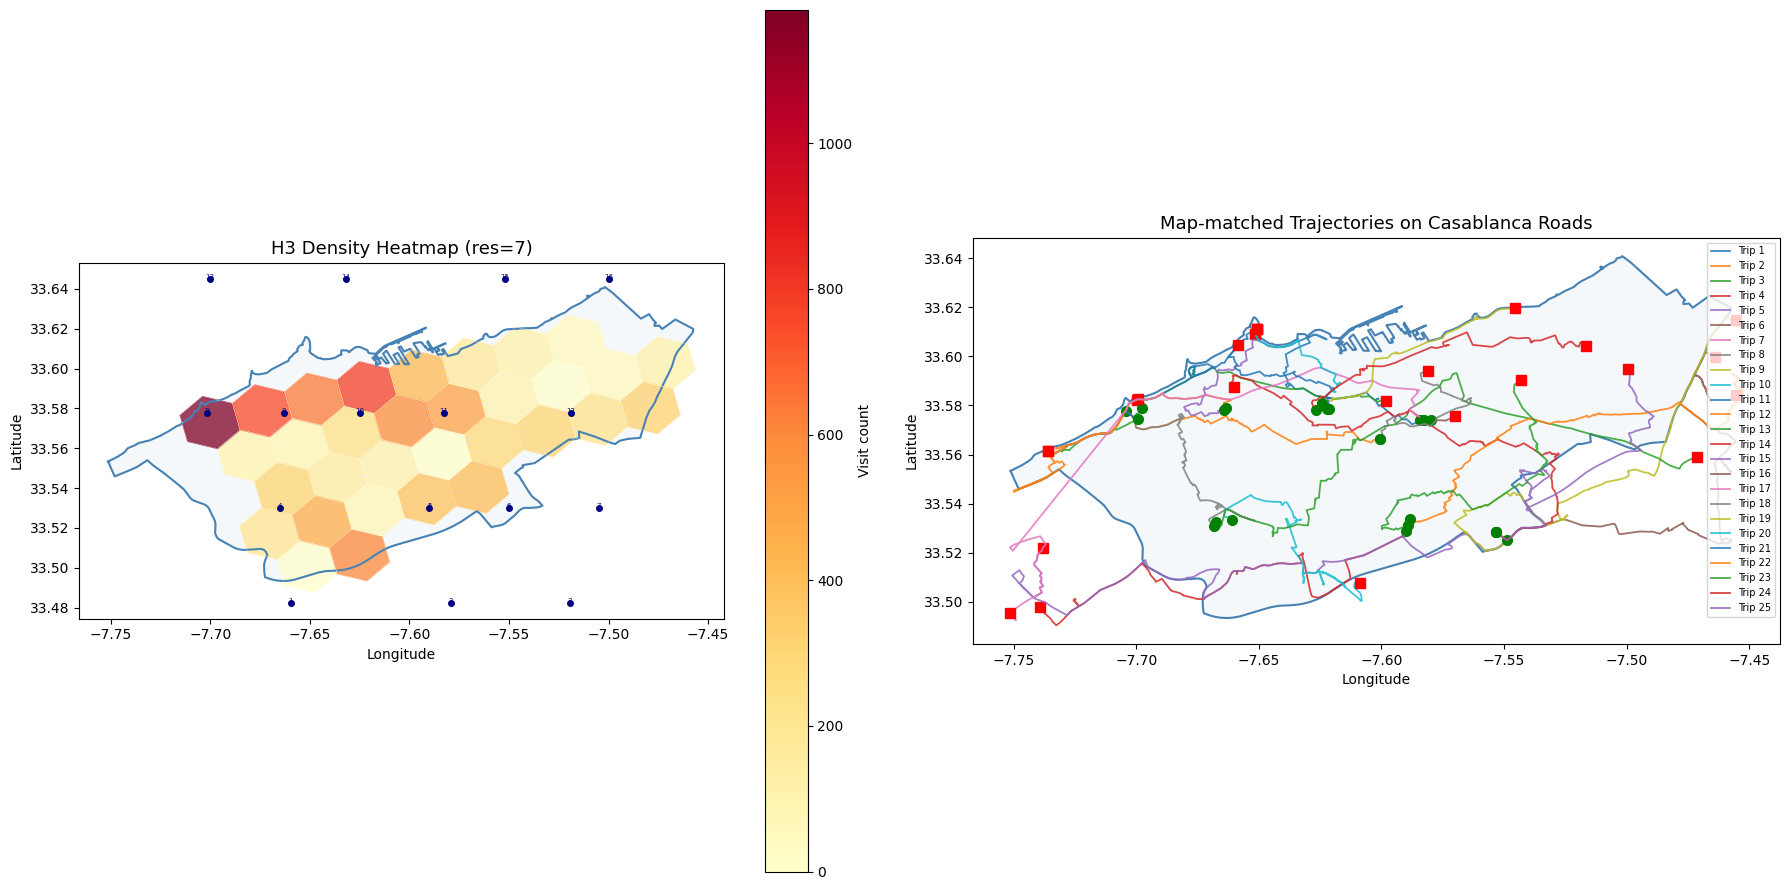

Saved -> casablanca_analysis.png


In [73]:
def plot_static(polygon, h3_agg, trip_results, zones_gdf):
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))

    # LEFT: H3 density heatmap
    ax = axes[0]
    px, py = polygon.exterior.xy
    ax.fill(px, py, alpha=0.05, color='steelblue')
    ax.plot(px, py, color='steelblue', linewidth=1.5,
            label='Casablanca boundary')
    vmax = max(h3_agg['visit_count'].max(), 1)
    cmap = plt.cm.YlOrRd
    for _, row in h3_agg.iterrows():
        vc = row['visit_count']
        if vc == 0:
            continue
        color = cmap(vc / vmax)
        hx, hy = row.geometry.exterior.xy
        ax.fill(hx, hy, color=color, alpha=0.75)
        ax.plot(hx, hy, color='white', linewidth=0.2)
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(0, vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Visit count')
    for _, zrow in zones_gdf.iterrows():
        ax.plot(zrow['centroid_lon'], zrow['centroid_lat'],
                'o', color='navy', markersize=4)
        ax.annotate(str(zrow['zone_id']),
                    (zrow['centroid_lon'], zrow['centroid_lat']),
                    fontsize=5, ha='center', color='navy')
    ax.set_title(f'H3 Density Heatmap (res={H3_RESOLUTION})', fontsize=13)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

    # RIGHT: trajectories
    ax2 = axes[1]
    ax2.fill(px, py, alpha=0.05, color='steelblue')
    ax2.plot(px, py, color='steelblue', linewidth=1.5)
    tab_colors = plt.cm.tab10.colors
    for i, res in enumerate(trip_results):
        pts  = res['trajectory']
        lons = [p['lon'] for p in pts]
        lats = [p['lat'] for p in pts]
        c    = tab_colors[i % len(tab_colors)]
        ax2.plot(lons, lats, color=c, linewidth=1.3, alpha=0.85,
                 label=f'Trip {i+1}')
        ax2.plot(lons[0],  lats[0],  'o', color='green', markersize=7)
        ax2.plot(lons[-1], lats[-1], 's', color='red',   markersize=7)
    ax2.set_title('Map-matched Trajectories on Casablanca Roads', fontsize=13)
    ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')
    ax2.legend(fontsize=7, loc='upper right')
    ax2.set_aspect('equal')

    plt.tight_layout()
    out = OUT_DIR / 'casablanca_analysis.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}')


if results:
    plot_static(CASA_POLYGON, H3_AGG, results, ZONES_GDF)


## 21  Interactive map — polygon + H3 density + trajectories + heatmap

In [77]:
def build_interactive_map(polygon, h3_agg, trip_results, zones_gdf):
    centre = polygon.centroid
    m = folium.Map(location=[centre.y, centre.x], zoom_start=12,
                   tiles='OpenStreetMap')

    # Casablanca polygon
    poly_fg = folium.FeatureGroup(name='Casablanca boundary', show=True)
    coords  = [(y, x) for x, y in polygon.exterior.coords]
    folium.Polygon(locations=coords, color='#1565C0', weight=2,
                   fill=True, fill_opacity=0.04,
                   tooltip='Casablanca boundary').add_to(poly_fg)
    poly_fg.add_to(m)

    # H3 density
    h3_fg  = folium.FeatureGroup(name='H3 density', show=True)
    vmax   = max(h3_agg['visit_count'].max(), 1)
    cmap_h = plt.cm.YlOrRd
    for cell, row in h3_agg.iterrows():
        vc = row['visit_count']
        if vc == 0:
            continue
        hex_col  = mcolors.to_hex(cmap_h(vc / vmax))
        boundary = h3.cell_to_boundary(cell)
        locs     = [(lat, lon) for lat, lon in boundary]
        folium.Polygon(
            locations=locs, color=hex_col, weight=0.3,
            fill=True, fill_color=hex_col, fill_opacity=0.65,
            tooltip=f'H3: {cell} | visits: {vc} | trips: {int(row["trip_count"])}',
        ).add_to(h3_fg)
    h3_fg.add_to(m)

    # Zone centroids
    zone_fg = folium.FeatureGroup(name='Zones', show=False)
    for _, zrow in zones_gdf.iterrows():
        folium.CircleMarker(
            location=[zrow['centroid_lat'], zrow['centroid_lon']],
            radius=6, color='navy', fill=True,
            fill_color='white', fill_opacity=0.8,
            popup=f"Zone {zrow['zone_id']}: {zrow['name']}<br>H3: {zrow['h3_cell']}",
        ).add_to(zone_fg)
    zone_fg.add_to(m)

    # Trajectories
    COLORS  = ['#E53935','#43A047','#F9A825','#8E24AA','#00ACC1']
    traj_fg = folium.FeatureGroup(name='Trajectories', show=True)
    for i, res in enumerate(trip_results):
        color   = COLORS[i % len(COLORS)]
        pts     = res['trajectory']
        latlons = [(p['lat'], p['lon']) for p in pts]
        folium.PolyLine(latlons, color=color, weight=3, opacity=0.85,
                        tooltip=f"Trip {res['trip_id']} | {len(pts)} pts"
                        ).add_to(traj_fg)
        folium.CircleMarker(location=latlons[0], radius=7, color=color,
                            fill=True, fill_color='#4CAF50',
                            popup=f"START zone {pts[0]['zone_id']}: {pts[0]['zone_name']}<br>H3: {pts[0]['h3_index']}"
                            ).add_to(traj_fg)
        folium.CircleMarker(location=latlons[-1], radius=7, color=color,
                            fill=True, fill_color='#F44336',
                            popup=f"END zone {pts[-1]['zone_id']}: {pts[-1]['zone_name']}<br>H3: {pts[-1]['h3_index']}"
                            ).add_to(traj_fg)
    traj_fg.add_to(m)

    # GPS heatmap layer
    heat_fg   = folium.FeatureGroup(name='GPS heatmap', show=False)
    heat_data = [[p['lat'], p['lon']]
                 for res in trip_results for p in res['trajectory']]
    HeatMap(heat_data, radius=14, blur=10,
            gradient={0.2:'blue', 0.5:'lime', 0.8:'orange', 1.0:'red'}
            ).add_to(heat_fg)
    heat_fg.add_to(m)

    folium.LayerControl().add_to(m)
    return m


if results:
    imap = build_interactive_map(CASA_POLYGON, H3_AGG, results, ZONES_GDF)
    imap.save(OUT_DIR / 'casablanca_trajectories.html')
    print('Interactive map saved -> casablanca_trajectories.html')
    display(imap)


Interactive map saved -> casablanca_trajectories.html


## 22  GPS density heatmap (dark theme)

In [76]:
if results:
    hm = folium.Map(
        location=[CASA_POLYGON.centroid.y, CASA_POLYGON.centroid.x],
        zoom_start=12, tiles='CartoDB dark_matter')
    heat_pts = [[p['lat'], p['lon']]
                for res in results for p in res['trajectory']]
    HeatMap(heat_pts, radius=15, blur=10, max_zoom=14,
            gradient={0.2:'blue', 0.5:'lime', 0.8:'orange', 1.0:'red'}
            ).add_to(hm)
    hm.save(OUT_DIR / 'casablanca_heatmap.html')
    print('Heatmap saved -> casablanca_heatmap.html')
    display(hm)


Heatmap saved -> casablanca_heatmap.html


## 23  Export — Kafka-ready JSON + flat DataFrame

In [ ]:
if results:
    out_json = OUT_DIR / 'processed_trajectories.json'
    with open(out_json, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Exported {len(results)} trajectories -> {out_json}')

    rows = []
    for res in results:
        for pt in res['trajectory']:
            rows.append({'trip_id': res['trip_id'], **pt})
    df_out = pd.DataFrame(rows)
    print(f'Flat DataFrame shape : {df_out.shape}')
    print(df_out.dtypes)
    df_out.head(5)


## 24  Performance notes & Spark / Flink readiness

### Single-thread throughput
| Step | Typical cost | Bottleneck |
|------|-------------|------------|
| parse + validate | < 1 ms/trip | — |
| `_sample_start` + waypoint adapt | < 2 ms/trip | numpy |
| `add_randomness` (graph copy) | 200-800 ms/trip | graph size |
| `nx.shortest_path` x n_waypoints | 50-300 ms/trip | graph traversal |
| `enrich_point` x n_pts | < 1 ms/pt | GeoPandas |
| `aggregate_h3` | O(n_pts) | dict ops |

> **Optimisation tip**: pre-build one noisy graph copy per Spark partition and reuse it across all trips in that partition — avoids per-trip graph copies.

### Spark batch (Week 5)
```python
G_bc       = sc.broadcast(G_ll)
polygon_bc = sc.broadcast(CASA_POLYGON)
zones_bc   = sc.broadcast(ZONES_GDF)
weights_bc = sc.broadcast(ZONE_WEIGHTS)

def process_partition(rows):
    rng     = np.random.default_rng()
    G_noisy = add_randomness(G_bc.value, rng, noise_factor=0.15)  # one copy per partition
    for row in rows:
        result = process_trajectory(
            str(row.TRIP_ID), row.POLYLINE,
            zones_gdf=zones_bc.value, weights=weights_bc.value,
            polygon=polygon_bc.value, G=G_noisy, rng=rng,
            randomness=0.3, n_waypoints=4,
        )
        if result:
            yield result

spark_df.rdd.mapPartitions(process_partition)
```

### Flink streaming (Week 4)
- `parse_polyline` + `validate_trajectory` → stateless `MapFunction`
- `_sample_start` + waypoint adapt → stateless (weights broadcast via `RichFunction.open()`)
- `snap_to_graph` + `compute_route` → stateful; cache `G_ll` in `RuntimeContext`
- `validate_route` → pure function, zero state
- `enrich_point` + `format_output` → Kafka sink serialiser